# 02 - Feature table inspection
Inspects `data/processed/features.csv` produced by `src/features.py`. Nothing here changes the data; it's a review aid.
All correlations use the **training period only** -- the post-gap test period stays unexamined.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/features.csv", parse_dates=["cycle_start_local", "sleep_start_local", "sleep_end_local"])
usable = df[df["exclude_reason"].isna()]
train = usable[~usable["is_test"]]
print(f"{len(df)} cycles | usable {len(usable)} | train {len(train)} | test {usable['is_test'].sum()}")
df["exclude_reason"].fillna("kept").value_counts()

440 cycles | usable 412 | train 358 | test 54


exclude_reason
kept               412
no_baseline_yet     11
no_recovery         10
dropped_score        4
calibrating          3
Name: count, dtype: int64

## 1. Exclusions
Every dropped cycle with its reason. `no_baseline_yet` = the first cycles, before 14 observations exist for the 30-day baseline.

In [2]:
df.loc[df["exclude_reason"].notna(), ["cycle_start_local", "recovery_score", "user_calibrating", "exclude_reason"]]

,cycle_start_local,recovery_score,user_calibrating,exclude_reason
0,2025-06-29 00:00:00.000,NaN,NaN,no_recovery
1,2025-06-30 03:42:15.588,89.0,True,calibrating
2,2025-07-01 04:09:27.381,95.0,True,calibrating
3,2025-07-02 05:45:39.757,94.0,True,calibrating
4,2025-07-03 04:06:07.770,96.0,False,no_baseline_yet
5,2025-07-04 05:55:56.622,28.0,False,no_baseline_yet
6,2025-07-05 01:25:51.486,27.0,False,no_baseline_yet
7,2025-07-06 03:18:52.405,82.0,False,no_baseline_yet
8,2025-07-07 05:52:44.069,54.0,False,no_baseline_yet
9,2025-07-08 02:03:34.430,65.0,False,no_baseline_yet


## 2. Personal baselines
HRV against its backward-looking 30-day baseline. The baseline lags the raw series by design: it only uses previous cycles.

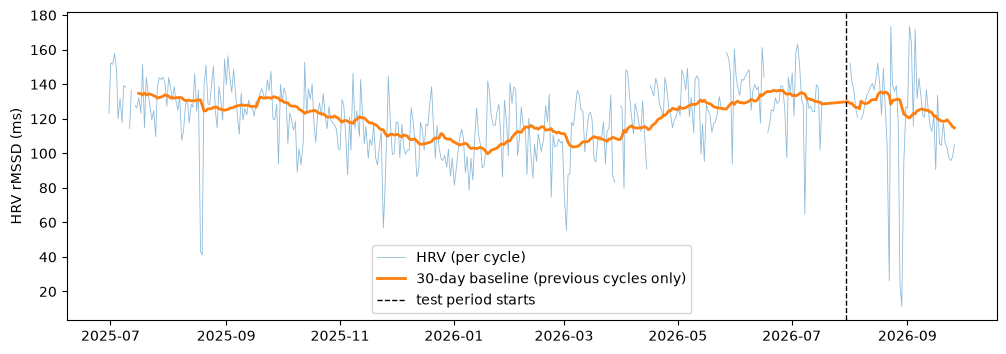

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["cycle_start_local"], df["hrv_rmssd_milli"], lw=0.6, alpha=0.5, label="HRV (per cycle)")
ax.plot(df["cycle_start_local"], df["hrv_baseline"], lw=2, label="30-day baseline (previous cycles only)")
ax.axvline(pd.Timestamp("2026-07-30"), color="k", ls="--", lw=1, label="test period starts")
ax.set_ylabel("HRV rMSSD (ms)"); ax.legend(); plt.show()

## 3. HRV: absolute vs relative to baseline
Both versions are in the model. How much do they differ on this data?

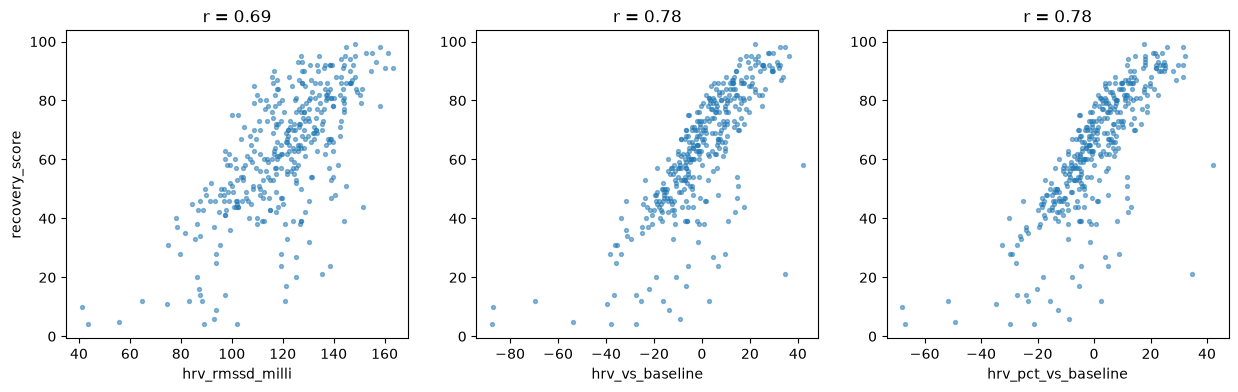

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["hrv_rmssd_milli", "hrv_vs_baseline", "hrv_pct_vs_baseline"]):
    ax.scatter(train[col], train["recovery_score"], s=8, alpha=0.5)
    ax.set_xlabel(col); ax.set_title(f"r = {train[col].corr(train['recovery_score']):.2f}")
axes[0].set_ylabel("recovery_score"); plt.show()

## 4. Why Set B: sleep performance vs. its raw ingredients
`sleep_performance_pct` is WHOOP's own composite (sleep obtained vs. sleep needed). Set B replaces it with the raw variables.

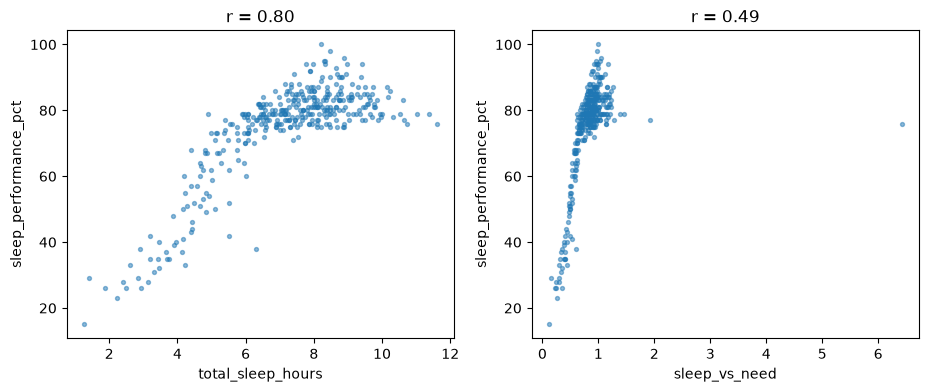

In [5]:
train = train.assign(sleep_vs_need=train["total_sleep_hours"] / train["sleep_need_total_hours"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["total_sleep_hours", "sleep_vs_need"]):
    ax.scatter(train[col], train["sleep_performance_pct"], s=8, alpha=0.5)
    ax.set_xlabel(col); ax.set_ylabel("sleep_performance_pct")
    ax.set_title(f"r = {train[col].corr(train['sleep_performance_pct']):.2f}")
plt.show()

## 5. Correlation of every Set B feature with recovery (training period)
Single-feature correlations only -- they ignore overlap between features, so they are a sanity check, not attribution (that's M2).

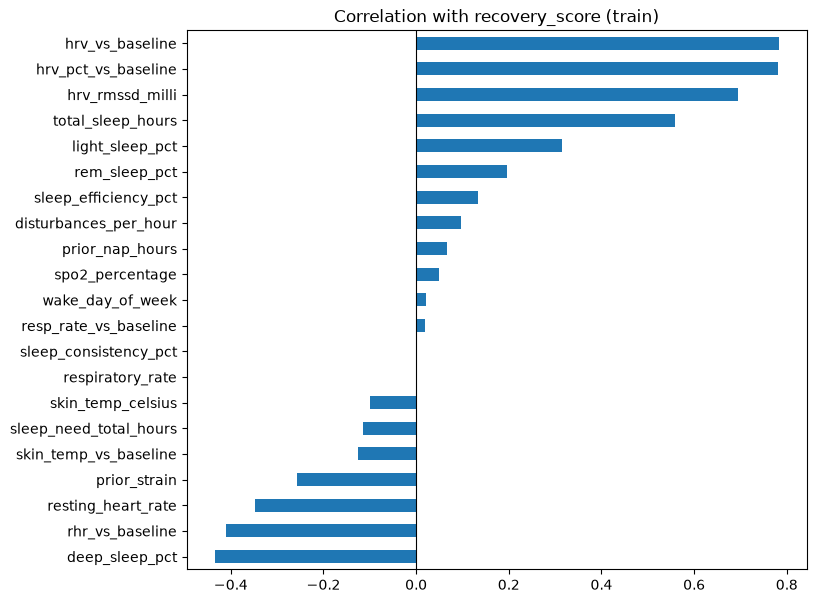

In [6]:
set_b = ["hrv_rmssd_milli", "hrv_vs_baseline", "hrv_pct_vs_baseline", "resting_heart_rate", "rhr_vs_baseline",
         "respiratory_rate", "resp_rate_vs_baseline", "skin_temp_celsius", "skin_temp_vs_baseline", "spo2_percentage",
         "total_sleep_hours", "light_sleep_pct", "deep_sleep_pct", "rem_sleep_pct", "sleep_efficiency_pct",
         "disturbances_per_hour", "sleep_consistency_pct", "sleep_need_total_hours", "prior_strain", "prior_nap_hours",
         "wake_day_of_week"]
corr = train[set_b].corrwith(train["recovery_score"]).sort_values()
corr.plot.barh(figsize=(8, 7), title="Correlation with recovery_score (train)"); plt.axvline(0, color="k", lw=0.8); plt.show()

## 6. Leakage spot-check: prior_strain must equal the previous cycle's strain

In [7]:
df[["cycle_start_local", "strain", "prior_strain", "prev_cycle_contiguous"]].iloc[100:106]

,cycle_start_local,strain,prior_strain,prev_cycle_contiguous
100,2025-10-07 00:35:44.507,14.274233,11.458176,True
101,2025-10-08 01:58:30.423,11.215050,14.274233,True
102,2025-10-09 01:27:12.742,9.603350,11.215050,True
103,2025-10-10 01:14:05.604,10.693315,9.603350,True
104,2025-10-11 03:13:12.436,16.802305,10.693315,True
105,2025-10-12 06:52:06.847,4.522002,16.802305,True


## 7. Open item: implausible deep-sleep shares
Cycles with the highest deep-sleep percentage. Short sleeps make percentages unstable.

In [8]:
usable.nlargest(5, "deep_sleep_pct")[["cycle_start_local", "deep_sleep_pct", "total_sleep_hours", "recovery_score"]]

,cycle_start_local,deep_sleep_pct,total_sleep_hours,recovery_score
379,2026-07-16 06:02:00.000,72.362635,1.267163,4.0
247,2026-03-04 04:01:54.993,69.375102,2.405978,12.0
130,2025-11-06 02:48:29.356,56.807648,1.409614,12.0
31,2025-07-30 04:33:48.253,56.167934,4.278868,48.0
237,2026-02-22 04:05:22.008,53.555138,2.898399,11.0
